In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [4]:
df = pd.read_csv("/Users/mr.tian/Desktop/CGMacros-003/CGMacros-003.csv")

In [5]:
df.head()

,Unnamed: 0,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path
0,0,2020-03-11 09:03:00,155.0,NaN,78.0,1.06164,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2020-03-11 09:04:00,155.0,NaN,81.0,1.15011,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2020-03-11 09:05:00,155.0,NaN,77.0,1.06164,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2020-03-11 09:06:00,155.0,NaN,86.0,1.15011,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2020-03-11 09:07:00,155.0,NaN,81.0,1.06164,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['Unnamed: 0', 'Timestamp', 'Libre GL', 'Dexcom GL', 'HR',
       'Calories (Activity)', 'METs', 'Meal Type', 'Calories', 'Carbs',
       'Protein', 'Fat', 'Fiber', 'Amount Consumed', 'Image path'],
      dtype='object')

In [7]:
# 1) Basic preprocessing (continue from existing df)
df = df.copy()
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Build one glucose series for analysis
if {"Libre GL", "Dexcom GL"}.issubset(df.columns):
    df["Glucose"] = df["Libre GL"].combine_first(df["Dexcom GL"])
elif "Libre GL" in df.columns:
    df["Glucose"] = df["Libre GL"]
elif "Dexcom GL" in df.columns:
    df["Glucose"] = df["Dexcom GL"]
else:
    raise ValueError("No glucose column found. Expected 'Libre GL' or 'Dexcom GL'.")

print("Rows in full dataset:", len(df))
print("Missing Timestamp:", df["Timestamp"].isna().sum())
print("Missing Glucose before interpolation:", df["Glucose"].isna().sum())


Rows in full dataset: 14565
Missing Timestamp: 0
Missing Glucose before interpolation: 0


In [8]:
# 2) Filter the specific day: 2020-03-15
target_patient = "CGMacros-003"
target_day = pd.to_datetime("2020-03-15").date()

keep_cols = [c for c in ["Timestamp", "Glucose", "Libre GL", "Dexcom GL"] if c in df.columns]
day_df = (
    df.loc[df["Timestamp"].dt.date == target_day, keep_cols]
      .sort_values("Timestamp")
      .copy()
)

# Fill tiny gaps to get a continuous curve for peak detection
day_df["Glucose"] = day_df["Glucose"].interpolate(limit_direction="both")

print(f"{target_patient} | {target_day} | rows={len(day_df)}")
print("Missing Glucose after interpolation:", day_df["Glucose"].isna().sum())
day_df.head()


CGMacros-003 | 2020-03-15 | rows=1440
Missing Glucose after interpolation: 0


,Timestamp,Glucose,Libre GL,Dexcom GL
5202,2020-03-15 00:00:00,87.800000,87.800000,111.0
5203,2020-03-15 00:01:00,87.866667,87.866667,111.0
5204,2020-03-15 00:02:00,87.933333,87.933333,111.0
5205,2020-03-15 00:03:00,88.000000,88.000000,111.0
5206,2020-03-15 00:04:00,88.066667,88.066667,111.0


In [9]:
# 3) Quick summary stats for the day
day_df["Glucose"].describe()


count    1440.000000
mean      103.122222
std        21.150325
min        83.000000
25%        90.200000
50%        95.533333
75%       105.900000
max       188.000000
Name: Glucose, dtype: float64

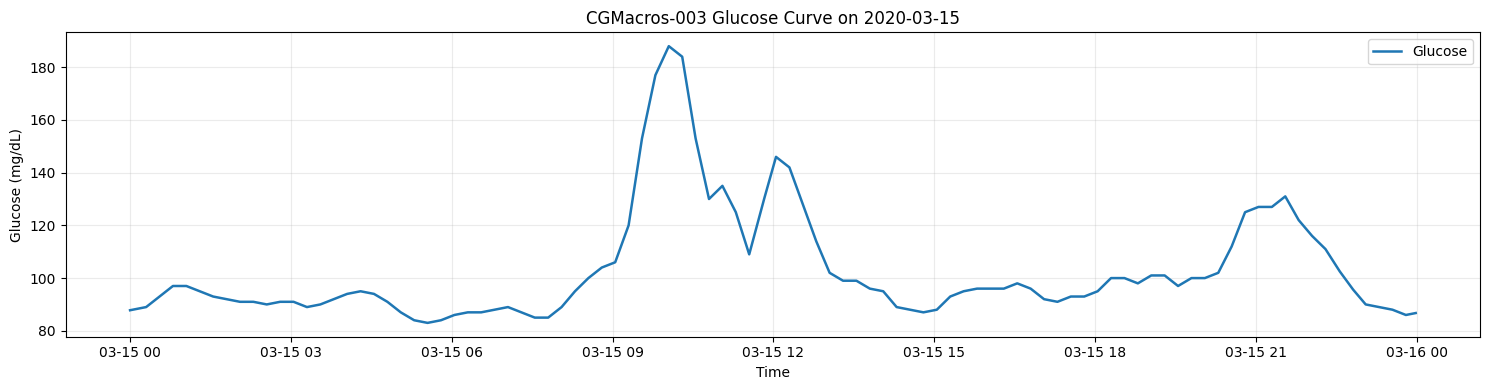

In [10]:
# 4) Plot glucose curve for the day
plt.figure(figsize=(15, 4))
plt.plot(day_df["Timestamp"], day_df["Glucose"], lw=1.8, color="#1f77b4", label="Glucose")
plt.title(f"{target_patient} Glucose Curve on {target_day}")
plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# 5) Detect major peaks
# Parameters are tuned for this 1-day minute-level curve:
# - height>=120: ignore low overnight bumps
# - distance=60: at least 60 minutes between two peaks
# - prominence>=10: keep peaks with meaningful rise/fall
signal = day_df["Glucose"].to_numpy()
peaks, properties = find_peaks(signal, height=120, distance=60, prominence=10)

peaks_df = day_df.iloc[peaks][["Timestamp", "Glucose"]].copy().reset_index(drop=True)
peaks_df["Prominence"] = properties.get("prominences", [])
peaks_df["Peak_Height"] = properties.get("peak_heights", [])

print(f"Detected major peaks: {len(peaks_df)}")
peaks_df


Detected major peaks: 3


,Timestamp,Glucose,Prominence,Peak_Height
0,2020-03-15 10:03:00,188.0,102.0,188.0
1,2020-03-15 12:03:00,146.0,37.0,146.0
2,2020-03-15 21:33:00,131.0,44.0,131.0


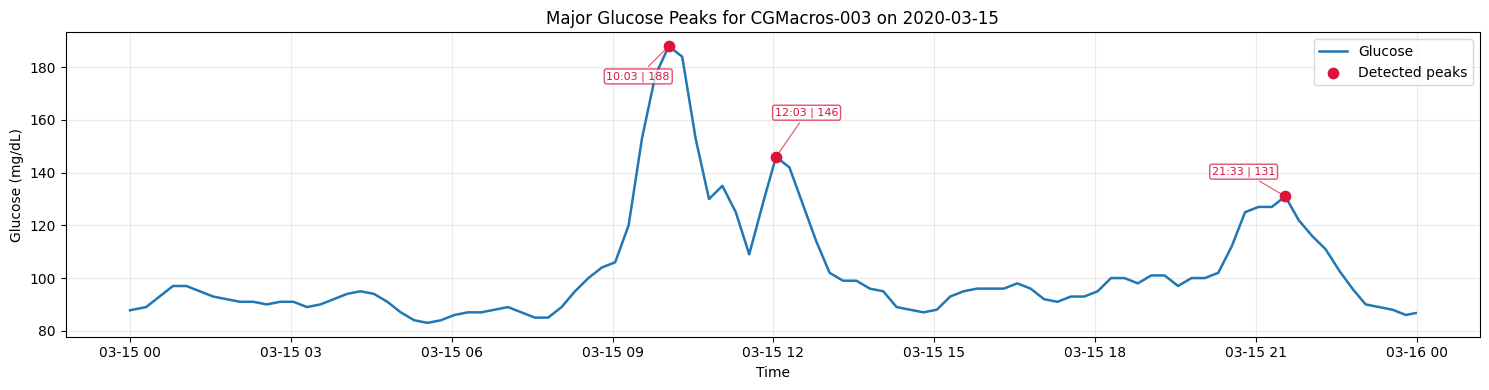

In [14]:
# 6) Visualize detected peaks on the curve
plt.figure(figsize=(15, 4))
plt.plot(day_df["Timestamp"], day_df["Glucose"], lw=1.8, color="#1f77b4", label="Glucose")

if len(peaks_df) > 0:
    plt.scatter(peaks_df["Timestamp"], peaks_df["Glucose"], color="crimson", s=55, zorder=3, label="Detected peaks")

    # Stagger labels to reduce overlap
    x_offsets = [-22, 22, -30, 30]
    y_offsets = [14, 28]

    for i, (_, row) in enumerate(peaks_df.iterrows()):
        # Move the first label downward so it does not collide with the title area
        if i == 0:
            dx, dy = -22, -18
        else:
            dx, dy = x_offsets[i % len(x_offsets)], y_offsets[i % len(y_offsets)]

        plt.annotate(
            f"{row['Timestamp'].strftime('%H:%M')} | {row['Glucose']:.0f}",
            (row["Timestamp"], row["Glucose"]),
            textcoords="offset points",
            xytext=(dx, dy),
            ha="center",
            va="top" if dy < 0 else "bottom",
            fontsize=8,
            color="crimson",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="crimson", alpha=0.75),
            arrowprops=dict(arrowstyle="-", color="crimson", lw=0.8, alpha=0.75),
        )

plt.title(f"Major Glucose Peaks for {target_patient} on {target_day}")
plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## 2-hour reflection

In about two hours, I focused on getting one clean, reproducible example done for **CGMacros-003 on 2020-03-15**.

What I got done:
- I checked the dataset columns and converted `Timestamp` to datetime.
- I built a single glucose series (`Glucose`) using Libre values first and Dexcom as fallback.
- I filtered the data to 2020-03-15 and plotted the full-day glucose curve.
- I used `find_peaks` to identify major glucose peaks and labeled them on the chart.
- I generated a small peak table with timestamp, glucose value, and prominence.

What worked well:
- The one-day focus made it easier to debug and tune quickly.
- Combining interpolation with peak constraints (`height`, `distance`, `prominence`) gave stable, readable peaks.
- Visualizing and tabulating peaks together helped me sanity-check results faster.

What did not work well:
- Peak detection is still sensitive to parameter choices; changing thresholds changes the number of peaks.
- I did not finish a full validation against meal timing/activity in this run.
- I also did not build a generalized pipeline for all days/patients yet.

If I spent more time:
- Additional time spent beyond the 2-hour window: **~30 minutes**.
- Next, I would align peaks with meal/event features (`Meal Type`, `Carbs`, `Calories`) to check whether detected peaks are physiologically meaningful.
- I would also run a small sensitivity test over multiple peak settings and report which settings are most robust.
